# Models, Approximation, and Error

**This notebook opens Unit 3, it assumes only arithmetic.**

Almost nothing in applied mathematics is computed exactly. We replace a hard problem with an easier
one we *can* solve, accept that the answer is a little wrong, and then, this is the part that matters
, **say how wrong**. That habit is the spine of this entire unit: derivatives get approximated by
finite differences, areas by rectangles, complicated functions by polynomials. Every one of them is
"solve a simpler problem, and track the error."

## Learning objectives

- Describe a **model** as a deliberate simplification, and say what was given up.
- Compute **absolute** and **relative** error, and explain when each is the useful one.
- Name the three places error comes from: the **inputs**, the **model**, and **floating-point arithmetic**.

## Background

If $\hat{v}$ is our approximation of a true value $v$, the **absolute error** is the raw gap and the
**relative error** is that gap as a fraction of the truth:

$$E_{\text{abs}} = |\hat{v} - v|, \qquad E_{\text{rel}} = \frac{|\hat{v} - v|}{|v|}$$

Relative error is usually the honest one, because it is **unitless**: an absolute error of 1 000 km²
sounds enormous until you learn the true value is 510 000 000 km². Relative error is often quoted as a
percentage.

Error arrives from three different directions, and it is worth being able to tell them apart:

1. **Inputs**, the numbers we start from were measured, and measurements are imprecise.
2. **The model**, we chose a simplified description of reality on purpose.
3. **Floating point**, the computer stores numbers with finite precision (this is what
   `U1-5_FloatingPoint-1_MachineEpsilon` is about; a number like $0.1$ has no exact binary form, so
   tiny errors creep into every arithmetic operation).

## This notebook covers

1. Estimating the surface area of the Earth.
2. Absolute vs relative error.
3. Where the error came from, the three sources, told apart.
4. A second example: approximating $\sin(\pi/8)$.

**Prerequisites:** `U1-5_FloatingPoint-1_MachineEpsilon`

**Dataset:** none, values entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. How big is the Earth?

Suppose you need the surface area of the Earth. The exact answer requires knowing the shape of the
planet in complete detail, every mountain, every trench. That problem is not solvable.

So we **model**: pretend the Earth is a perfect sphere. Then the answer is a formula anyone can use,

$$A = 4\pi r^2$$

and all we need is a radius. That substitution, an impossible problem for a solvable one, is the
move this whole unit is built on. The price is that the answer is now wrong, and we should find out
by how much.

In [2]:
# the sphere model, with the Earth's equatorial radius in km
r_equatorial = 6378.0
area_model = 4 * math.pi * r_equatorial**2

# the accepted value, measured by satellite
area_true = 510_072_000.0

print(f"model  (sphere, r = {r_equatorial:.0f} km) : {area_model:15,.0f} km^2")
print(f"accepted value                        : {area_true:15,.0f} km^2")

model  (sphere, r = 6378 km) :     511,185,933 km^2
accepted value                        :     510,072,000 km^2


## 2. Absolute and relative error

The two numbers differ. **How badly?** That question has two reasonable answers.

- **Absolute error**: the raw difference, in km². Big-sounding, and in the same units as the thing itself.
- **Relative error**: the difference as a fraction of the truth. Unitless, and the one that tells you
  whether the approximation is any good.

A useful rule: absolute error answers *"how far off, in real units?"*; relative error answers
*"should I be worried?"*

In [3]:
def errors(estimate, truth):
    absolute = abs(estimate - truth)
    relative = absolute / abs(truth)
    return absolute, relative

abs_err, rel_err = errors(area_model, area_true)
print(f"absolute error : {abs_err:15,.0f} km^2   <- sounds enormous")
print(f"relative error : {rel_err:15.5f}        =  {rel_err*100:.3f}%   <- actually quite good")

absolute error :       1,113,933 km^2   <- sounds enormous
relative error :         0.00218        =  0.218%   <- actually quite good


Over a million square kilometres off, and yet the model is accurate to about **0.2%**. Both statements
are true, and that is exactly why you report the relative error: the absolute number is unreadable
without knowing the scale.

## 3. Where did the error come from?

Three sources, and they are worth separating because they respond to different fixes.

**Source 1, the inputs.** We picked the *equatorial* radius, 6378 km. But the Earth is slightly
squashed, so the *polar* radius is about 6357 km, and the *mean* radius is about 6371 km. Which one is
"the" radius? The choice is an input, and changing it changes the answer.

In [4]:
for label, r in [("polar     ", 6357.0), ("mean      ", 6371.0), ("equatorial", 6378.0)]:
    a = 4 * math.pi * r**2
    _, rel = errors(a, area_true)
    print(f"r = {r:.0f} km ({label}) -> {a:15,.0f} km^2   relative error {rel*100:6.3f}%")

r = 6357 km (polar     ) ->     507,825,245 km^2   relative error  0.440%
r = 6371 km (mean      ) ->     510,064,472 km^2   relative error  0.001%
r = 6378 km (equatorial) ->     511,185,933 km^2   relative error  0.218%


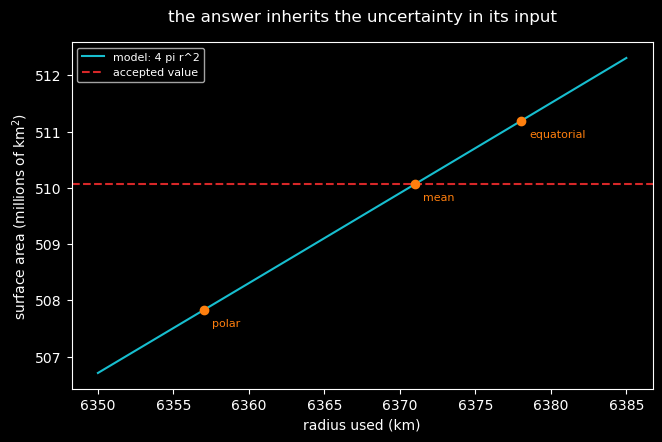

In [5]:
# how sensitive is the answer to the input? sweep the radius across the plausible range
radii = np.linspace(6350, 6385, 200)
areas = 4 * np.pi * radii**2

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(radii, areas / 1e6, color="tab:cyan", label="model: 4 pi r^2")
ax.axhline(area_true / 1e6, color="tab:red", ls="--", label="accepted value")
for label, r in [("polar", 6357.0), ("mean", 6371.0), ("equatorial", 6378.0)]:
    ax.plot(r, 4 * np.pi * r**2 / 1e6, "o", color="tab:orange")
    ax.annotate(label, (r, 4 * np.pi * r**2 / 1e6), textcoords="offset points",
                xytext=(6, -12), color="tab:orange", fontsize=8)

ax.set_xlabel("radius used (km)")
ax.set_ylabel("surface area (millions of km$^2$)")
ax.set_title("the answer inherits the uncertainty in its input", pad=15)
ax.legend(fontsize=8)
plt.show()

**Source 2, the model.** Even given a perfect radius, "the Earth is a sphere" is a decision we made.
The planet is an oblate spheroid with mountains on it. That gap doesn't shrink by measuring more
carefully, it is baked into the choice of formula. A better model (an ellipsoid) would cost more
effort and buy more accuracy; that trade is yours to make deliberately.

**Source 3, floating point.** The computer stores numbers in binary with finite precision, so even
arithmetic it does "exactly" carries a tiny error. It is far too small to matter here, around $10^{-16}$
relative, but it sets a hard floor on accuracy that §3.4 runs straight into when we start dividing by
very small numbers.

In [6]:
# the floating-point floor: a classic demonstration that 0.1 + 0.2 is not 0.3
print(f"0.1 + 0.2      = {0.1 + 0.2:.20f}")
print(f"0.3            = {0.3:.20f}")
print(f"equal?           {0.1 + 0.2 == 0.3}")
print(f"the gap        = {abs((0.1 + 0.2) - 0.3):.2e}   <- about 1e-16, the scale of this error source")

0.1 + 0.2      = 0.30000000000000004441
0.3            = 0.29999999999999998890
equal?           False
the gap        = 5.55e-17   <- about 1e-16, the scale of this error source


## 4. A second example: $\sin(\pi/8)$

Here is a smaller, more arithmetic case. Suppose you need $\sin(\pi/8)$ and have no calculator. A
rough answer is $3/8 = 0.375$.

Where does that come from? For now, treat it simply as *someone's estimate*, a convenient fraction
close to the right answer. (§3.9 explains where approximations like this actually come from, and how
to make them as accurate as you like. It is one of the payoffs at the end of this unit.)

The point right now is only that we can **measure how good it is** without knowing where it came from.

In [7]:
estimate = 3 / 8
truth = math.sin(math.pi / 8)

abs_err, rel_err = errors(estimate, truth)
print(f"estimate       : {estimate:.6f}")
print(f"true value     : {truth:.6f}")
print(f"absolute error : {abs_err:.6f}")
print(f"relative error : {rel_err*100:.2f}%")

estimate       : 0.375000
true value     : 0.382683
absolute error : 0.007683
relative error : 2.01%


About 2% off. Whether that is acceptable depends entirely on what you are doing with it, and
"acceptable for this purpose" is a judgment, not a mathematical fact. Reporting the error is what
lets someone else make that judgment.

## 5. Summary

- A **model** trades an unsolvable problem for a solvable one. The trade always costs accuracy; the
  discipline is to measure the cost.
- **Absolute error** $|\hat{v} - v|$ is in the original units; **relative error**
  $|\hat{v} - v| / |v|$ is unitless and usually the honest summary.
- Error comes from three separable places: **inputs** (measured imprecisely), **the model** (a
  deliberate simplification), and **floating point** (the machine's finite precision, ~$10^{-16}$).
- Better inputs fix the first, a better model fixes the second, and nothing fixes the third.

This pattern recurs for the whole unit: §3.4 approximates derivatives with finite differences, §3.8
approximates areas with rectangles, §3.9 approximates functions with polynomials. Each one has an
error, and each time we will measure it.

Next: the idea that makes calculus possible, what happens as a quantity gets arbitrarily small
(`U3-2_Limits-1_ApproachingALimit`).